In [30]:
from utils.utilities import get_engine
import pandas as pd
import numpy as np
import plotly.graph_objects as go
import matplotlib.pyplot as plt
from pandas.plotting import autocorrelation_plot
from statsmodels.tsa.arima.model import ARIMA
from datetime import datetime
from dateutil.relativedelta import relativedelta
from sklearn.metrics import mean_squared_error
import math

In [31]:
engine = get_engine(country = 'AU')

In [32]:
end_date = datetime.today().date()
start_date = end_date - relativedelta(days = 365 * 3)
stock_code = 'JBH'
query = f"""
    SELECT
        date,
        open,
        high,
        low,
        close
    FROM transaction
    WHERE 
        stock_code = '{stock_code}'
        AND
        date >= DATE '{start_date}'
        AND
        date <= DATE '{end_date}'
    ORDER BY date
"""
df = pd.read_sql_query(query, engine)
df = df.fillna(method='ffill').fillna(method='bfill').reset_index(drop = True)
df

,date,open,high,low,close
0,2021-01-28,42.470651,42.864657,41.863222,42.076641
1,2021-01-29,42.519898,43.398205,42.224392,42.495274
2,2021-02-01,41.477427,42.199773,41.149089,41.649807
3,2021-02-02,41.518466,42.519897,41.370713,42.454231
4,2021-02-03,42.684073,43.004203,42.478861,42.716908
...,...,...,...,...,...
768,2024-01-18,59.380001,59.919998,58.549999,59.070000
769,2024-01-19,58.490002,58.490002,58.150002,58.270000
770,2024-01-22,58.490002,58.490002,58.150002,58.270000
771,2024-01-23,58.490002,58.490002,58.150002,58.270000


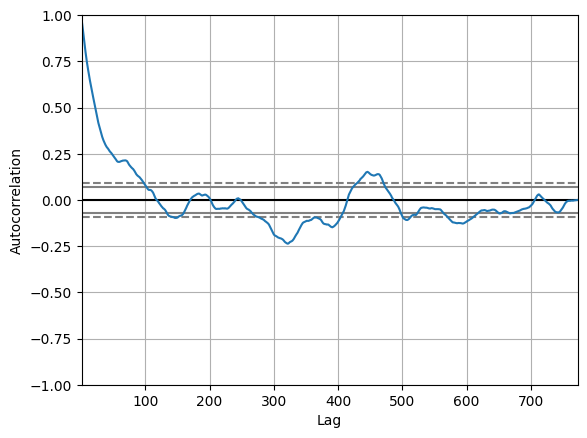

In [33]:
autocorrelation_plot(df['close'])
plt.show()

In [34]:
# # fit model
# model = ARIMA(df['close'], order=(10,5,30))
# model_fit = model.fit()
# # summary of fit model
# print(model_fit.summary())
# # line plot of residuals
# residuals = pd.DataFrame(model_fit.resid)
# residuals.plot()
# plt.show()
# # density plot of residuals
# residuals.plot(kind='kde')
# plt.show()
# # summary stats of residuals
# print(residuals.describe())

Test RMSE: 0.543


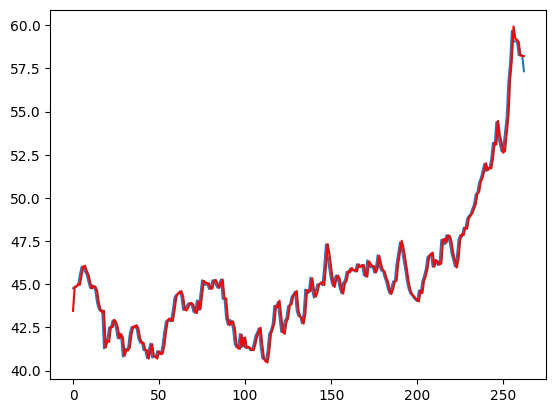

In [35]:
X = df['close'].values
size = int(len(X) * 0.66)
train, test = X[0:size], X[size:len(X)]
history = [x for x in train]
predictions = list()
# walk-forward validation
for t in range(len(test)):
    model = ARIMA(history, order=(3,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test[t]
    history.append(obs)

# evaluate forecasts
rmse = math.sqrt(mean_squared_error(test, predictions))
print('Test RMSE: %.3f' % rmse)
# plot forecasts against actual outcomes
plt.plot(test)
plt.plot(predictions, color='red')
plt.show()

In [36]:
# while day < DAY_RANGE:
#     last_x = np.array([prediction_df['close_pred'].iloc[-window:].to_numpy()])
#     scaled_x = transformer(last_x)
#     new_price = inv_transformer(model.predict(scaled_x)[0][0])

#     next_date = prediction_df['date'].iloc[-1]
#     while True:
#         next_date += timedelta(days=1)
#         # Check if the current date is a weekend (Saturday or Sunday)
#         if next_date.weekday() not in [5, 6]:
#             break

In [37]:
new_history = []
new_predictions = []
new_date = []
for i in range(60):
    model = ARIMA(history + new_history, order=(3,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    new_predictions.append(yhat)
    new_history.append(yhat)

fig = go.Figure(data=[
    go.Scatter(x = list(range(len(history))), y = predictions + new_predictions, name = 'Predict'),
    go.Scatter(x = list(range(len(history))), y = test, name = 'True'),
])
fig.show()